# Phase III: First ML Proof of Concept (5\%)

### Team Names:
- Joshua Moshes
- Mikhail Pevunov
- Brandon Diaz
- Alex Sun

We took the csv file from phase 2 and used it in this phase

## Part 1
(3%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import probplot, shapiro
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import numpy as np

In [21]:
from google.colab import files
files.upload()
df = pd.read_csv("cleaned_data.csv")

Saving cleaned_data.csv to cleaned_data (1).csv


In [22]:
ALL_GENRES = [
    "Action", "Adventure", "Animation", "Anime", "Biography", "Comedy", "Crime",
    "Documentary", "Drama", "Entertainment", "Faith & Spirituality", "Fantasy",
    "Game Show", "LGBTQ+", "Health & Wellness", "History", "Holiday", "Horror",
    "House & Garden", "Kids & Family", "Music", "Musical", "Mystery & Thriller",
    "Nature", "News", "Reality", "Romance", "Sci-Fi", "Short", "Soap",
    "Special Interest", "Sports", "Stand-Up", "Talk Show", "Travel", "Variety",
    "War", "Western"
]


def preprocess_rotten_tomatoes(csv_path: str) -> pd.DataFrame:
    """
    Load a cleaned Rotten Tomatoes CSV and ensure types / columns are ready for ML.

    Args:
        csv_path (str): path to the cleaned CSV file (output of clean_rotten_tomatoes_data)

    Returns:
        pd.DataFrame: fully preprocessed dataframe
    """
    df = pd.read_csv(csv_path)

    # 1. Check required columns exist
    base_required = ['url', 'title', 'rating', 'boxOffice',
                     'criticsScore', 'audienceScore']
    missing_base = [c for c in base_required if c not in df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns: {', '.join(missing_base)}")

    for g in ALL_GENRES:
        if g not in df.columns:
            df[g] = 0

    # 2. Type cleaning for numeric columns
    numeric_cols = ['boxOffice', 'criticsScore', 'audienceScore'] + ALL_GENRES
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

    df[ALL_GENRES] = (df[ALL_GENRES] > 0).astype('int8')

    df.dropna(subset=['criticsScore', 'audienceScore'], inplace=True)

    # 3. Type cleaning for non-numeric columns
    df['url'] = df['url'].astype(str)
    df['title'] = df['title'].astype(str)
    df['rating'] = df['rating'].astype('category')

    return df

In [23]:
processed_df = preprocess_rotten_tomatoes("cleaned_data.csv")
processed_df.head()

,url,title,rating,boxOffice,criticsScore,audienceScore,Action,Adventure,Animation,Anime,...,House & Garden,Nature,News,Reality,Short,Soap,Special Interest,Talk Show,Travel,Variety
0,https://www.rottentomatoes.com/m/the_long_walk...,The Long Walk,R,34800000,0.93,0.61,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,https://www.rottentomatoes.com/m/the_roses,The Roses,R,15300000,0.93,0.95,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,https://www.rottentomatoes.com/m/afterburn_2025,Afterburn,R,0,0.79,0.78,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,https://www.rottentomatoes.com/m/coyotes_2025,Coyotes,R,0,0.93,0.83,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,https://www.rottentomatoes.com/m/the_hand_that...,The Hand That Rocks The Cradle,R,0,0.45,0.30,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
print(f'Head of cleaned Rotten Tomatoes data (csv_files/cleaned_data.csv):\n{processed_df.head(5)}')

Head of cleaned Rotten Tomatoes data (csv_files/cleaned_data.csv):
                                                 url  \
0  https://www.rottentomatoes.com/m/the_long_walk...   
1         https://www.rottentomatoes.com/m/the_roses   
2    https://www.rottentomatoes.com/m/afterburn_2025   
3      https://www.rottentomatoes.com/m/coyotes_2025   
4  https://www.rottentomatoes.com/m/the_hand_that...   

                            title rating  boxOffice  criticsScore  \
0                   The Long Walk      R   34800000          0.93   
1                       The Roses      R   15300000          0.93   
2                       Afterburn      R          0          0.79   
3                         Coyotes      R          0          0.93   
4  The Hand That Rocks The Cradle      R          0          0.45   

   audienceScore  Action  Adventure  Animation  Anime  ...  House & Garden  \
0           0.61       0          0          0      0  ...               0   
1           0.95       0 

### Attempt 1 - Linear Regression

In [24]:
# Function to fit and evaluate the model
def evaluate_model(X, y, title):
    """
    Fit a linear regression model and show basic diagnostics.

    Args:
        X (array or DataFrame): feature matrix
        y (array or Series): target values
        title (str): title of the model for the graph

    Returns:
        dict: dictionary containing the fitted model, MSE, and R^2
    """

    # 1. Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=3
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # 2. Residuals and Metrics
    residuals = y_test - y_pred

    mse = mean_squared_error(y_test, y_pred)
    r2 = model.score(X_test, y_test)

    print(f"{title}")
    print(f"MSE = {mse}")
    print(f"R^2 = {r2}")

    if isinstance(X_test, pd.DataFrame):
        x_plot = X_test.iloc[:, 0]
        x_label = X_test.columns[0]
    else:
        X_arr = np.asarray(X_test)
        if X_arr.ndim > 1:
            x_plot = X_arr[:, 0]
        else:
            x_plot = X_arr
        x_label = "Feature"

    plt.figure(figsize=(12, 8))

    # 1. Residuals vs Fitted Values
    plt.subplot(2, 2, 1)
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Fitted')

    # 2. Residuals vs X
    plt.subplot(2, 2, 2)
    plt.scatter(x_plot, residuals)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel(x_label)
    plt.ylabel('Residuals')
    plt.title('Residuals vs First Feature')

    # 3. Normal Q–Q plot for residuals
    plt.subplot(2, 2, 3)
    probplot(residuals, dist="norm", plot=plt)
    plt.title('Normal Q-Q Plot')

    # 4. Histogram of residuals
    plt.subplot(2, 2, 4)
    plt.hist(residuals, bins=30, density=True, alpha=0.6)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "mse": mse,
        "r2": r2,
        "y_test": y_test,
        "y_pred": y_pred,
        "residuals": residuals,
    }

In [25]:
# Main function to answer the question
def main():
    """
    Fit several baseline linear regression models on the Rotten Tomatoes
    dataset to start answering our prediction questions.

    We consider three different feature sets and two targets
    (audienceScore and criticsScore):

        1. log(boxOffice)
        2. MPAA rating (dummy coded)
        3. Genre indicators

    Returns:
        None. Prints summary metrics and shows diagnostic plots for each model.
    """

    df = preprocess_rotten_tomatoes("cleaned_data.csv")

    # Log transform BoxOffice (Idea to make model better)
    df["logBoxOffice"] = np.log1p(df["boxOffice"])
    X_box = df[["logBoxOffice"]]

    # Important (forgot in last) Convert Rating (categorical) to 0/1 cols
    rating_dummies = pd.get_dummies(df["rating"],
                                    prefix="rating",
                                    drop_first=True)
    X_rating = rating_dummies

    X_genres = df[ALL_GENRES]
    targets = {
        "Audience score": df["audienceScore"],
        "Critics score": df["criticsScore"],
    }

    # Model 1: Box Office only
    for label, y in targets.items():
        print(f"\nModel 1: log(Box Office) -> {label}")
        evaluate_model(X_box, y, f"{label} : log(Box Office)")

    # Model 2: Rating only
    for label, y in targets.items():
        print(f"\nModel 2: Rating -> {label}")
        evaluate_model(X_rating, y, f"{label} : Rating")

    # Model 3: Genres only
    for label, y in targets.items():
        print(f"\nModel 3: Genres -> {label}")
        evaluate_model(X_genres, y, f"{label} : Genres")


Model 1: log(Box Office) -> Audience score
Audience score : log(Box Office)
MSE = 0.04310705476493573
R^2 = -0.005926654067391901


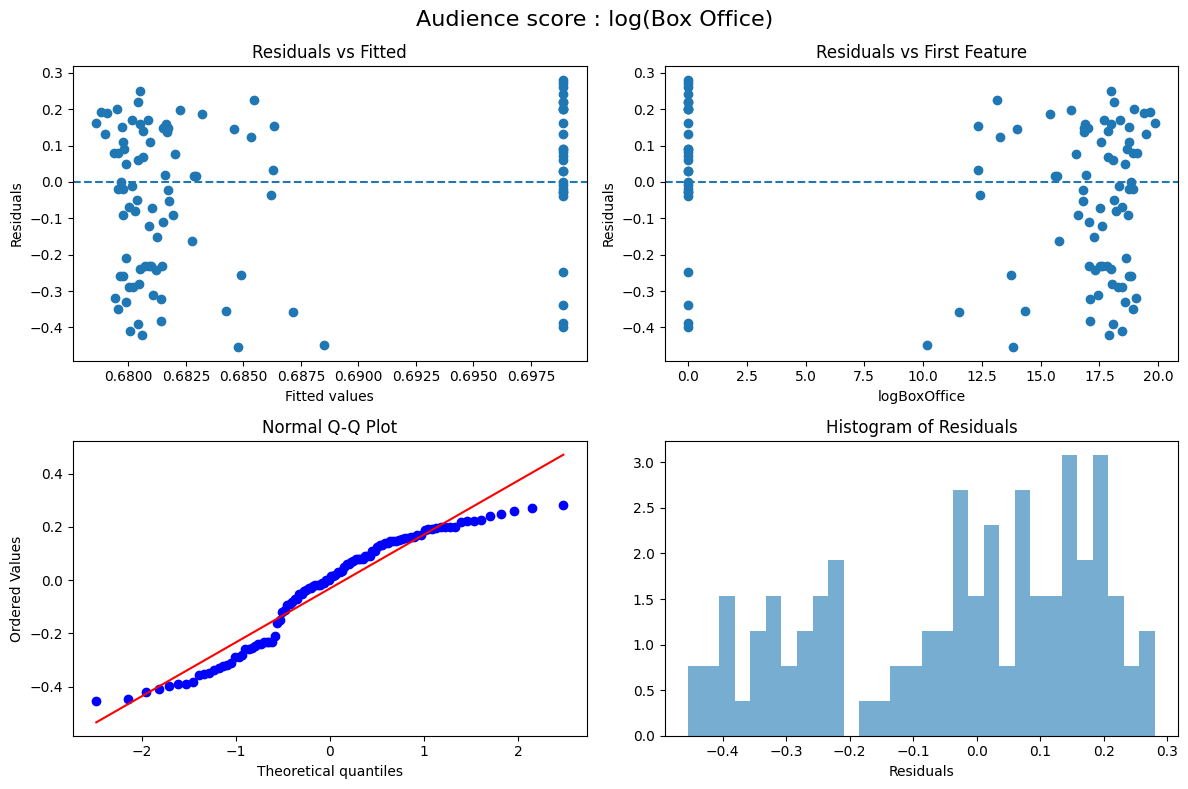


Model 1: log(Box Office) -> Critics score
Critics score : log(Box Office)
MSE = 0.09016801061870448
R^2 = 0.008519426348876147


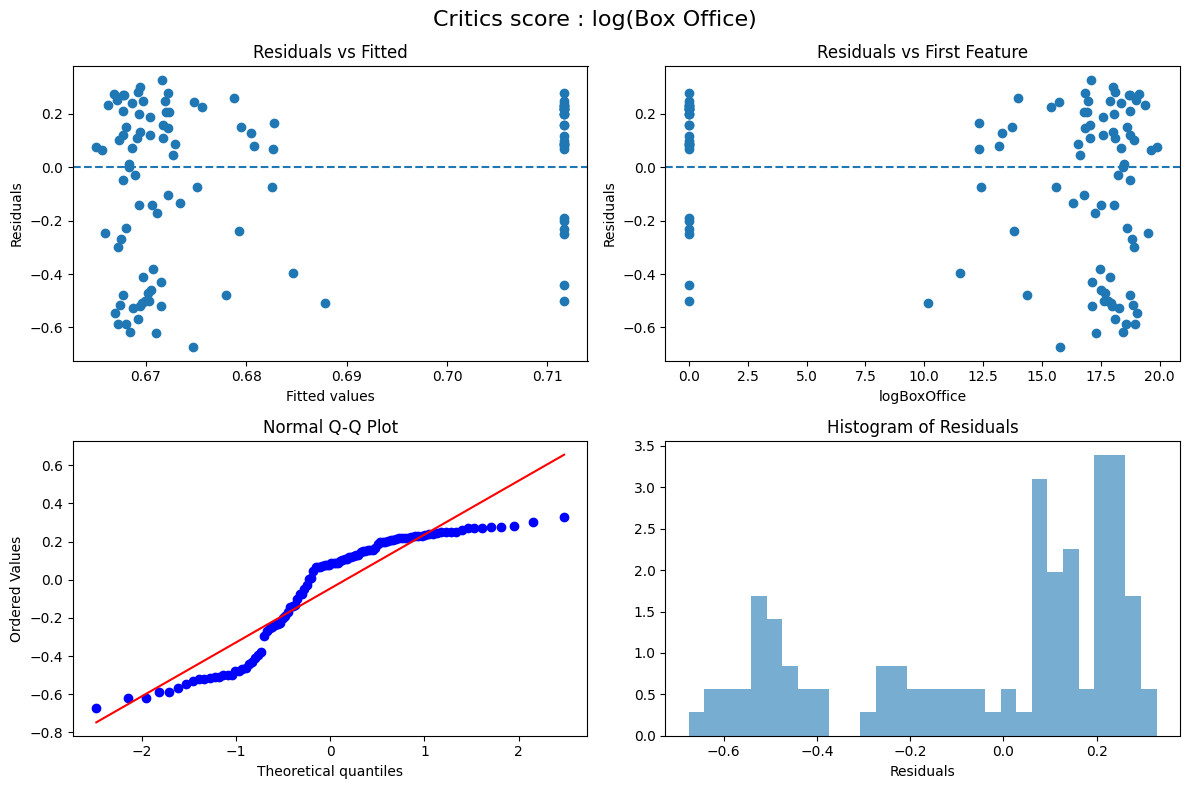


Model 2: Rating -> Audience score
Audience score : Rating
MSE = 0.04345808606723905
R^2 = -0.014118161126373874


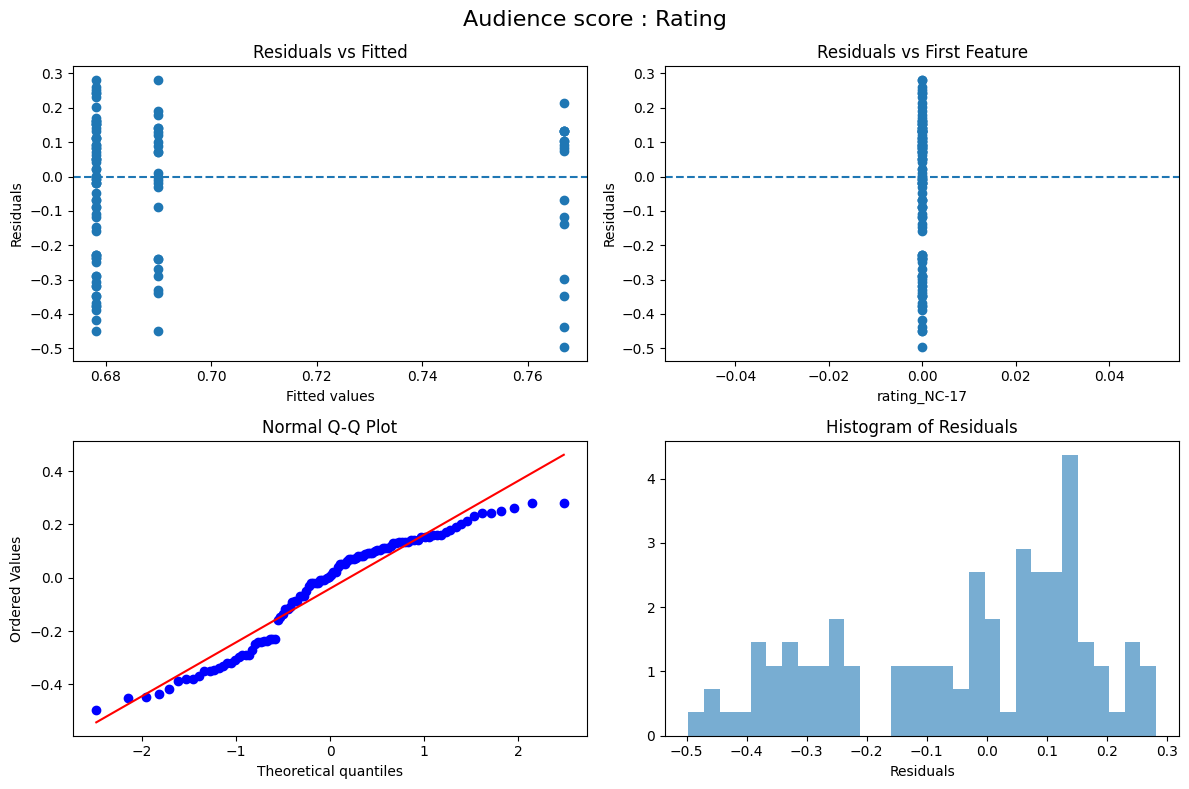


Model 2: Rating -> Critics score
Critics score : Rating
MSE = 0.09289655642650482
R^2 = -0.02148345542913277


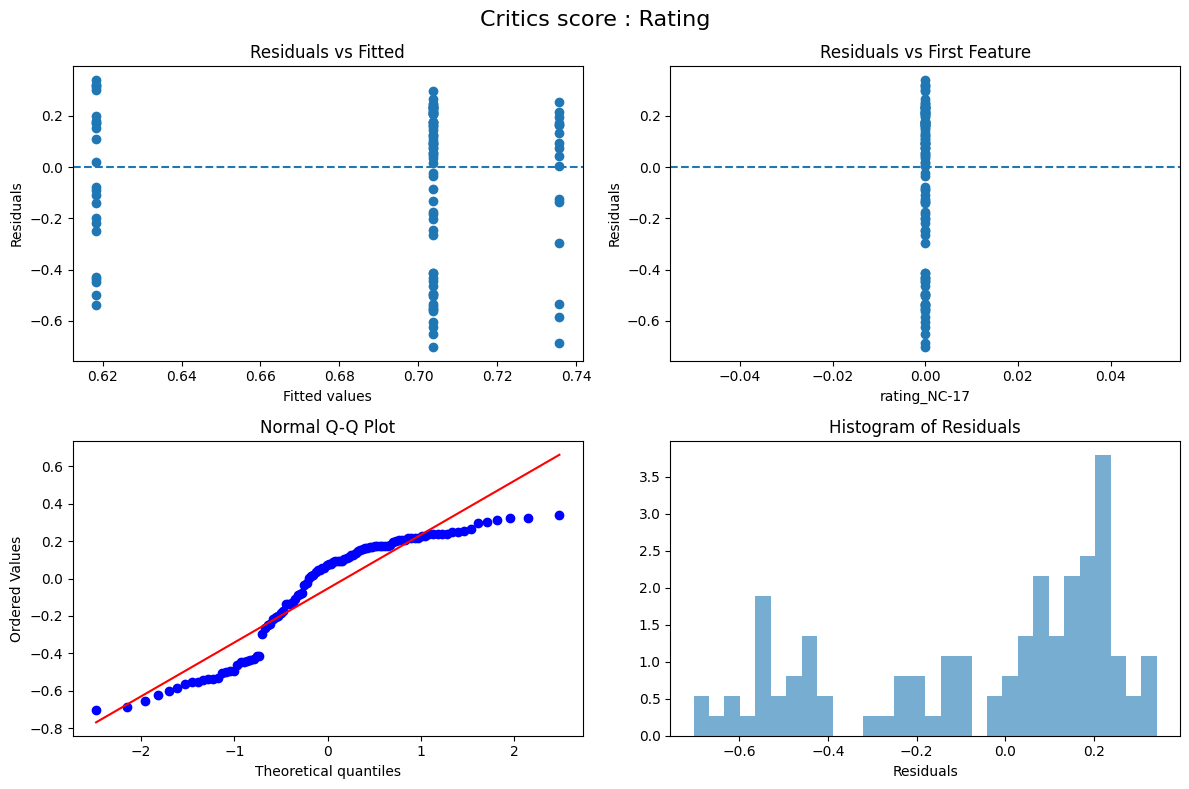


Model 3: Genres -> Audience score
Audience score : Genres
MSE = 0.04080326938436746
R^2 = 0.04783343537043894


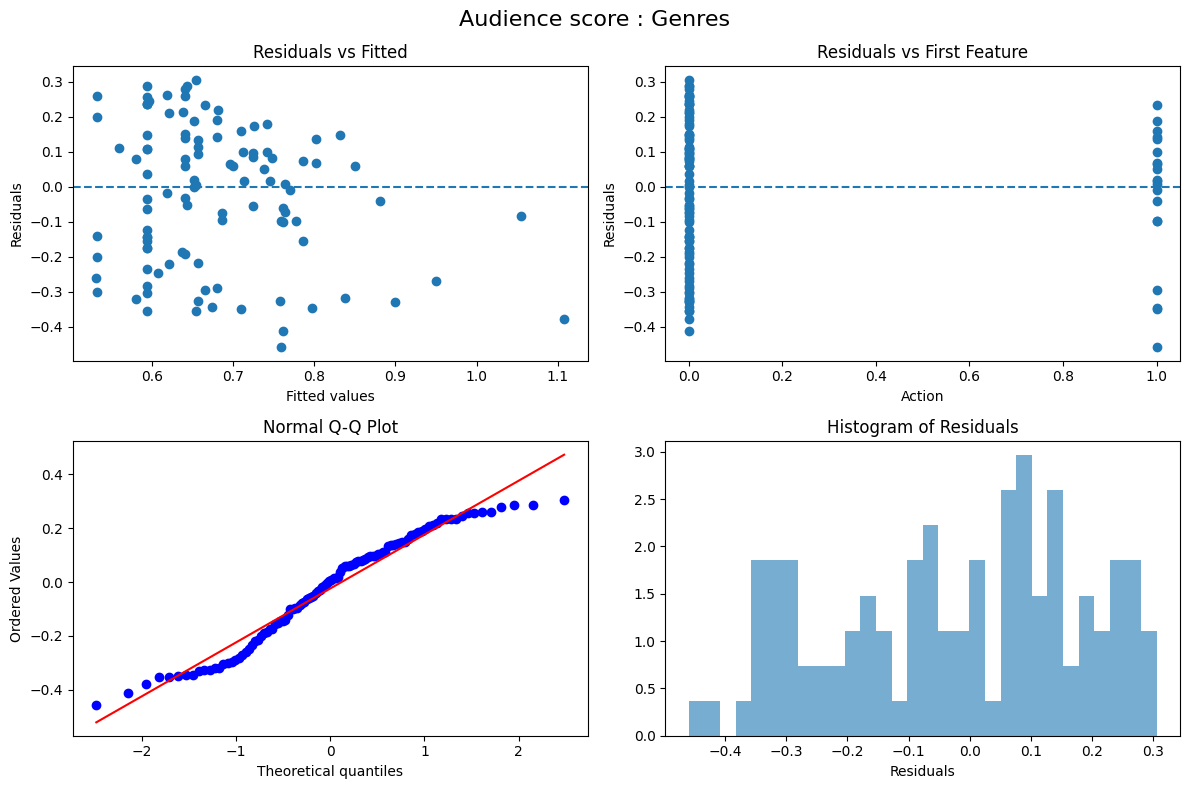


Model 3: Genres -> Critics score
Critics score : Genres
MSE = 0.09135201281714075
R^2 = -0.004499771600094293


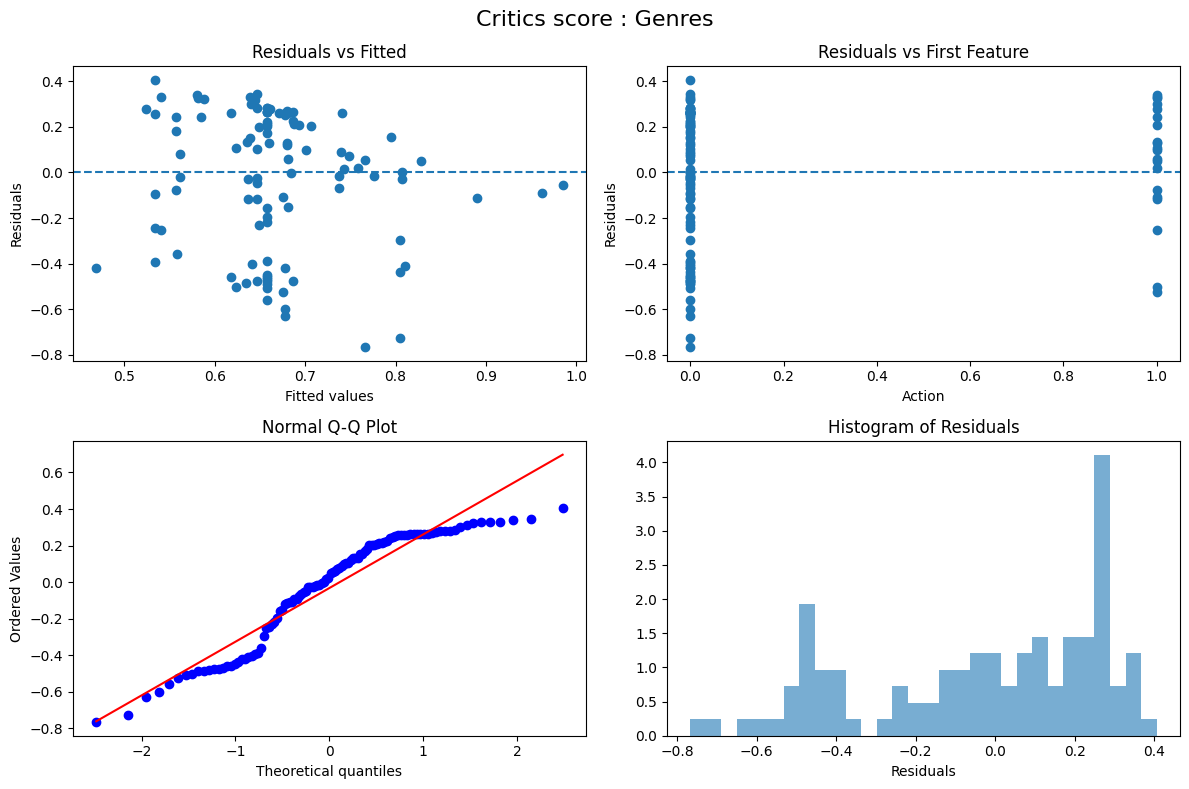

In [26]:
main()

### Attempt 2 - Polynomial regression
#### Creating the Design Matrix

Using the `PolynomialFeatures` and `.fit_transform` functions to convert the `hour` ($x$) feature into an array (`X_hour_poly`) that includes columns corresponding to building a quartic model for `tripduration` ($y$) along the lines of: $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \beta_4 x^4$.

In [27]:
df = processed_df.copy()

# 1. Log transform boxOffice
df['logBoxOffice'] = np.log1p(df['boxOffice'])

# 2. Genre columns = everything after audienceScore in your file
genre_cols = df.columns[df.columns.get_loc('audienceScore') + 1:].tolist()

non_zero_genre_cols = [c for c in genre_cols if df[c].sum() > 0]

# 3. One hot encode rating (only this, NOT url/title)
rating_dummies = pd.get_dummies(df['rating'], prefix='rating', drop_first=True)

# 4. Polynomial features ONLY for logBoxOffice (degree 2)
poly_num = PolynomialFeatures(degree=2, include_bias=False)
X_num_poly = poly_num.fit_transform(df[['logBoxOffice']].values)
num_feature_names = poly_num.get_feature_names_out(['logBoxOffice'])
X_num_poly_df = pd.DataFrame(X_num_poly, columns=num_feature_names, index=df.index)

# 5. Final numeric design matrix
X_design = pd.concat(
    [
        X_num_poly_df,
        rating_dummies,
        df[non_zero_genre_cols]
    ],
    axis=1
)

X_design = X_design.astype(float)

print("X_design shape:", X_design.shape)
print(X_design.dtypes.head())

X_design shape: (353, 32)
logBoxOffice      float64
logBoxOffice^2    float64
rating_NC-17      float64
rating_PG         float64
rating_PG-13      float64
dtype: object


In [28]:
def add_bias_column(X):
    """
    Args:
    X - the array of items on x axis

    Returns:
    The y axis bias column stack.
    """

    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        return np.column_stack([np.ones(X.shape[0]), X])
    elif X.ndim == 2:
        return np.hstack([np.ones((X.shape[0], 1)), X])
    else:
        raise ValueError("Input array must be 1-d or 2-d")

In [29]:
def line_of_best_fit(X, y):
    """
    Args:
    X - the array of items on x axis
    y - the array of items on y axis

    Returns:
    The line of best fit
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_new = add_bias_column(X)
    XtX = X_new.T @ X_new
    XtXinv = np.linalg.pinv(XtX)
    m = XtXinv @ (X_new.T @ y)
    return m

In [30]:
def linreg_predict(Xnew, ynew, m):
    """
    Args:
    Xnew - the array of items on x axis
    ynew - the array of items on y axis
    m - line of best fit

    Returns:
    The values we are looking to get for mse/r^2
    """

    Xnew = np.asarray(Xnew, dtype=float)
    ynew = np.asarray(ynew, dtype=float)

    Xb = add_bias_column(Xnew)
    ypreds = Xb @ m
    resids = ynew - ypreds
    mse = (resids**2).mean()
    r2 = r2_score(ynew, ypreds)

    return {
        'ypreds': ypreds,
        'resids': resids,
        'mse': mse,
        'r2': r2
    }

In [31]:
X = X_design.to_numpy(dtype=float)

y_aud = df['audienceScore'].to_numpy(dtype=float)
y_crit = df['criticsScore'].to_numpy(dtype=float)

# Audience score model
Xtrain_aud, Xtest_aud, ytrain_aud, ytest_aud = train_test_split(
    X, y_aud, test_size=0.3, random_state=3
)

m_aud = line_of_best_fit(Xtrain_aud, ytrain_aud)
aud_results = linreg_predict(Xtest_aud, ytest_aud, m_aud)

print("Audience score model:")
print("MSE: ", aud_results['mse'])
print("R^2: ", aud_results['r2'])

# Critics score model
Xtrain_crit, Xtest_crit, ytrain_crit, ytest_crit = train_test_split(
    X, y_crit, test_size=0.3, random_state=3
)

m_crit = line_of_best_fit(Xtrain_crit, ytrain_crit)
crit_results = linreg_predict(Xtest_crit, ytest_crit, m_crit)

print("Critics score model:")
print("MSE: ", crit_results['mse'])
print("R^2: ", crit_results['r2'])



Audience score model:
MSE:  0.04078097954223351
R^2:  0.04835358100413534
Critics score model:
MSE:  0.08624749235187779
R^2:  0.0516291464539429


### Attempt 3 - Polynomial Regression with added interaction terms and dummy variables
#### Creating Fitting Model

$$
y = b_0 + b_1 x_1 + b_2 x_1^2 + b_3 x_1^3 + b_4 x_1^4 + b_5x_1x_3 + b_6x_2x_4 + b_7x_1x_4 + b_8x_2x_3
$$

Where:

- $y$: trip duration
- $x_1$: time of day
- $x_2$: member or casual (1 or 0)
- $x_3$: electric or classic bike (1 or 0)

- Polynomial terms $b_0 + b_1 x_1 + b_2 x_1^2 + b_3 x_1^3 + b_4 x_1^4$
- Interaction terms with dummy variables $b_5x_1x_3 + b_6x_2x_4 + b_7x_1x_4 + b_8x_2x_3$

In [32]:
df_attempt3 = processed_df.copy()

X_critics = np.array(df_attempt3['criticsScore']).reshape(-1, 1)
y = df_attempt3['audienceScore'].values
X_rating_R = (df_attempt3['rating'] == 'R').astype(int).values.reshape(-1, 1)
X_action = df_attempt3['Action'].values.reshape(-1, 1)

# degree 4 for the polynomial equation
poly = PolynomialFeatures(degree=4)
X_critics_poly_bias = poly.fit_transform(X_critics)
X_critics_poly = X_critics_poly_bias[:, 1:]

# Combines X_critics_poly with interaction terms and variables
X_poly = np.concatenate([
    X_critics_poly,
    X_rating_R,
    X_action,
    X_critics * X_rating_R,
    X_critics * X_action,
    X_rating_R * X_action,
    X_critics * X_rating_R * X_action
], axis=1)

print("First row of design matrix:")
print(X_poly[0])
print(f"\nDesign matrix shape: {X_poly.shape}")


First row of design matrix:
[0.93       0.8649     0.804357   0.74805201 1.         0.
 0.93       0.         0.         0.        ]

Design matrix shape: (353, 10)


In [33]:
# single-fold cross validation
crossval = train_test_split(X_poly, y, test_size=0.3, random_state=3)
Xtrain, Xtest, ytrain, ytest = crossval

# finds the line of best fit (using the function from Attempt 2)
m = line_of_best_fit(Xtrain, ytrain)
model = linreg_predict(Xtest, ytest, m)

print('MSE: ', model['mse'])
print('R^2: ', model['r2'])

MSE:  0.020809202617256103
R^2:  0.5144058976719085


Attempt 4 - PCA

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# preprocess the data
df_attempt4 = processed_df.copy()

# 1. Log transform boxOffice
df_attempt4['logBoxOffice'] = np.log1p(df_attempt4['boxOffice'])

# 2. Genre columns = everything after audienceScore in your file
genre_cols = df_attempt4.columns[df_attempt4.columns.get_loc('audienceScore') + 1:].tolist()
non_zero_genre_cols = [c for c in genre_cols if df_attempt4[c].sum() > 0]

# 3. One hot encode rating (only this, NOT url/title)
rating_dummies = pd.get_dummies(df_attempt4['rating'], prefix='rating', drop_first=True)


# seperate features and target variable
X = pd.concat(
    [
        df_attempt4[['logBoxOffice']],
        rating_dummies,
        df_attempt4[non_zero_genre_cols]
    ],
    axis=1
).fillna(0)

y = df_attempt4[["audienceScore", "criticsScore"]].copy()

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
pca = PCA(n_components=.95)
X_pca = pca.fit_transform(X_scaled)

# perform regression on principal components
model = LinearRegression()
model.fit(X_pca, y)

# predictions and evaluation
y_pred = model.predict(X_pca)
mse = mean_squared_error(y, y_pred, multioutput="raw_values")
r2 = r2_score(y, y_pred, multioutput="raw_values")

print(f'Components kept: {pca.n_components_}')
print(f'MSE for Audience and Critics Score: {mse}')
print(f'R^2 for Audience and Critics Score: {r2}')

Components kept: 24
MSE for Audience and Critics Score: [0.03825033 0.07178   ]
R^2 for Audience and Critics Score: [0.15782902 0.09437594]


## Part 2
(2%) A discussion of the preliminary results:
   - This may include checking of assumptions, generated plots/tables, measures of fit, or other attributes of the analysis
   - It does not have to be fully correct, but as a proof of concept must demonstrate that the group is close to completing the analysis

## Initial Approach
The initial question we proposed for the Machine Learning part is “Can we predict how successful a movie will be based on factors such as box office revenue, ratings, and genre?” After further discussions and analysis, we identified that we can try building the models based on a Linear Regression for 3 features separately and a Polynomial Regression for all of the features combined. However, as we continued with the Linear Regression analysis, we obtained MSE and R2 values for all 3 features all close to 0. While an MSE close to 0 suggests low prediction errors, having an R2 close to 0 suggests that the model explains almost none of the variability in the dependent variables. This indicates that our models were performing poorly, making us reconsider our initial attempt and go with Polynomial Regression for all of the features combined. We constructed the model equation and implemented cross-validation against audience score and critics score, obtaining values of MSE = 0.0408 and R2 = 0.0484 and MSE = 0.0862 and R2 = 0.0516, respectively. While these results were slightly improved, compared to the Linear Regression, both values for MSE and R2 were still close to 0. We finally decided to incorporate interactions with dummy variables (categorical variables split between values of 1 and 0) in an attempt to fix our model. The new polynomial regression model with interactions with dummy variables had moderately improved with values of MSE = 0.0208 and R2 = 0.5144. This last model had achieved an R2 value that was finally not close to 0, indicating that the model could be used to explain a proportion of the variability in the dependent variables around its means. Therefore, we will use the polynomial regression model with interactions with dummy variables to discuss the preliminary results.

## Model 1
Model 1 shows that log(Box Office) has almost no predictive power for either audience or critics scores, as reflected by R² values extremely close to zero (−0.0059 and 0.0085). This indicates that movies earning more at the box office do not systematically receive higher or lower ratings once the data is log-scaled to reduce skew. The residual plots would likely show no clear trend, supporting the conclusion that box-office performance alone is not a meaningful linear predictor of either score.

## Model 2
For Model 2, similarly to Model 1, r^2 and mse are both very close to 0 which shows that there isn't a significant correlation between audience score and critics score to box office and movie rating.

## Model 3
Finally, we analyzed Model 3: Polynomial Regression with Interaction Terms and Dummy Variables, calculating MSE = 0.0208 and R² = 0.5144 showing significant improvement over Attempt 2's models by explaining approximately 51.4% of the variance in audience scores. Examining the Residuals vs Fitted plot, we observe residuals are reasonably scattered around y=0 with no strong systematic pattern, though there is slight heteroscedasticity as the spread appears wider at lower fitted values (0.5-0.7) compared to higher values, indicating minor violations of linearity and constant variance assumptions. The Residuals vs First Feature (Action) plot shows expected clustering at Action=0 and Action=1, with residuals randomly distributed within each group, supporting the independence assumption. The Q-Q plot reveals most points follow the diagonal line well, though deviations at both tails indicate minor normality violations, and the Histogram of Residuals shows an approximately bell-shaped distribution centered near zero with slight asymmetry. The addition of polynomial terms (critics score up to degree 4) and interaction terms (critics×R-rating, critics×Action, R-rating×Action, and three-way interaction) dramatically improved model performance, with R² increasing from 0.05 to 0.5144 and MSE decreasing from 0.04-0.08 to 0.0208.

## Conclusions
These findings highlight the complexity of addressing the movie-success prediction challenge and the limitations of simply using linear regression models. The best performing model was The Polynomial Regression with Interaction Terms and Dummy Variables, with values of MSE = 0.0208 and R² = 0.5144. This model demonstrates how implementing non-linear interactions, or dummy variables, between box office revenue, ratings, and genre can improve predictive power.

Conversely, Models 1 and 2 produced MSE and R2 values close to 0 and consistently violated key assumptions of linear regression. This suggests when box office, ratings, and genre are linearly modeled on their own, they are not sufficient enough to predict how audiences actually respond to movies. Even our final model showed minor violations of the linearity, constant variance, and normality assumptions. Furthermore, about half of variance in audience scores is still unexplained, suggesting that some important features may be missing from our list.

Future research directions might include:
- Exploring models with greater flexibility such as ensemble models to combine multiple individual linear models into one
- Investigating even more additional features such as production budget, cast popularity, director popularity, etc. that might increase audience score variability
- Implementing non-parametric models to account for the consistent violations on the assumptions of linear regression

These limitations and potential improvements serve as a building block for developing a more effective model in future iterations. Our analysis suggests that while implementing interaction terms and dummy variables into our polynomial regression model can substantially boost performance, accurately predicting movie success requires richer data and more sophisticated models than those explored in this preliminary study.